In [2]:
import geopandas as gpd
from pathlib import Path

# 1) Read England+Wales outline and go to BNG
REG = gpd.read_file("regions.geojson")
REG = REG.to_crs(27700)

In [3]:
REG

,FID,RGN24CD,RGN24NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E12000001,North East,417315,600357,-1.728870,55.29702,12201951-50af-4e67-bd5e-bc5e19b04b9b,"MULTIPOLYGON (((450166.813 525927.223, 450030...."
1,2,E12000002,North West,350014,506279,-2.772390,54.44944,0a07bcad-79b5-41b4-8e47-7ab3831f733d,"MULTIPOLYGON (((327740.463 373788.528, 327751...."
2,3,E12000003,Yorkshire and The Humber,446902,448736,-1.287140,53.93265,1e65ebb6-acff-4cfd-b6e5-5e3dca036baa,"MULTIPOLYGON (((495375.86 422557.274, 495976.5..."
3,4,E12000004,East Midlands,477658,322635,-0.849710,52.79572,ec7a03af-0d6a-41a5-90f4-6a93e9b22d34,"MULTIPOLYGON (((552879.895 326705.959, 552800...."
4,5,E12000005,West Midlands,386293,295477,-2.203600,52.55697,42e5f029-56ae-4947-ac95-ee7f44a564cc,"POLYGON ((403283.11 368354.867, 403411.353 368..."
5,6,E12000006,East of England,571076,263235,0.504178,52.24073,11865ded-43ee-4d72-b16e-32ad5da0e51d,"MULTIPOLYGON (((570491.024 181422.027, 570442...."
6,7,E12000007,London,517517,178394,-0.308630,51.49229,9cd5cec9-fa74-4bdc-b4a5-91ac2a0efcfb,"MULTIPOLYGON (((515975.34 172549.825, 516013.0..."
7,8,E12000008,South East,470064,172925,-0.993090,51.45099,83b83902-d369-421d-a016-26b418854ddd,"MULTIPOLYGON (((428925.224 84884.647, 428869.6..."
8,9,E12000009,South West,285016,102566,-3.633420,50.81119,f459acca-1472-47f1-bac1-b0f83db429f8,"MULTIPOLYGON (((83938.378 5430.787, 83828.48 5..."


In [4]:
# 2) Get bounds for all England+Wales regions
# If your file includes only England, just use its total_bounds.
minx, miny, maxx, maxy = REG.total_bounds

# 3) Define a 2x3 grid
nx, ny = 3, 2  # columns x rows
dx = (maxx - minx) / nx
dy = (maxy - miny) / ny


tiles = []
tid = 1
for j in range(ny):          # rows (south→north)
    for i in range(nx):      # cols (west→east)
        x0 = minx + i*dx
        y0 = miny + j*dy
        x1 = x0 + dx
        y1 = y0 + dy
        # bbox string in EPSG:27700 order: minx,miny,maxx,maxy
        tiles.append((f"T{tid}", f"{int(x0)},{int(y0)},{int(x1)},{int(y1)}"))
        tid += 1

# 4) Save a simple CSV for reference/pasting
with open("tiles_coarse_ew.csv","w") as f:
    f.write("tile_id,bbox\n")
    for t in tiles:
        f.write(f"{t[0]},{t[1]}\n")

print("6 tiles:")
for t in tiles:
    print(t)


6 tiles:
('T1', '82607,5424,273580,331480')
('T2', '273580,5424,464553,331480')
('T3', '464553,5424,655526,331480')
('T4', '82607,331480,273580,657536')
('T5', '273580,331480,464553,657536')
('T6', '464553,331480,655526,657536')


In [12]:
import pandas as pd
from shapely.geometry import box

def tiles_from_grid(gdf_regions: gpd.GeoDataFrame, nx: int, ny: int) -> gpd.GeoDataFrame:
    minx, miny, maxx, maxy = gdf_regions.total_bounds
    dx = (maxx - minx) / nx
    dy = (maxy - miny) / ny
    geoms, ids = [], []
    tid = 1
    for j in range(ny):      # rows (south→north)
        for i in range(nx):  # cols (west→east)
            x0, y0 = minx + i*dx, miny + j*dy
            x1, y1 = x0 + dx, y0 + dy
            geoms.append(box(x0, y0, x1, y1))
            ids.append(f"T{tid}")
            tid += 1
    return gpd.GeoDataFrame({"tile_id": ids}, geometry=geoms, crs=27700)

In [16]:
tiles = tiles_from_grid(REG, 3, 2)

In [18]:
tiles.iloc[0, :]

tile_id                                                    T1
geometry    POLYGON ((273580.32017766614 5424.788278571825...
Name: 0, dtype: object

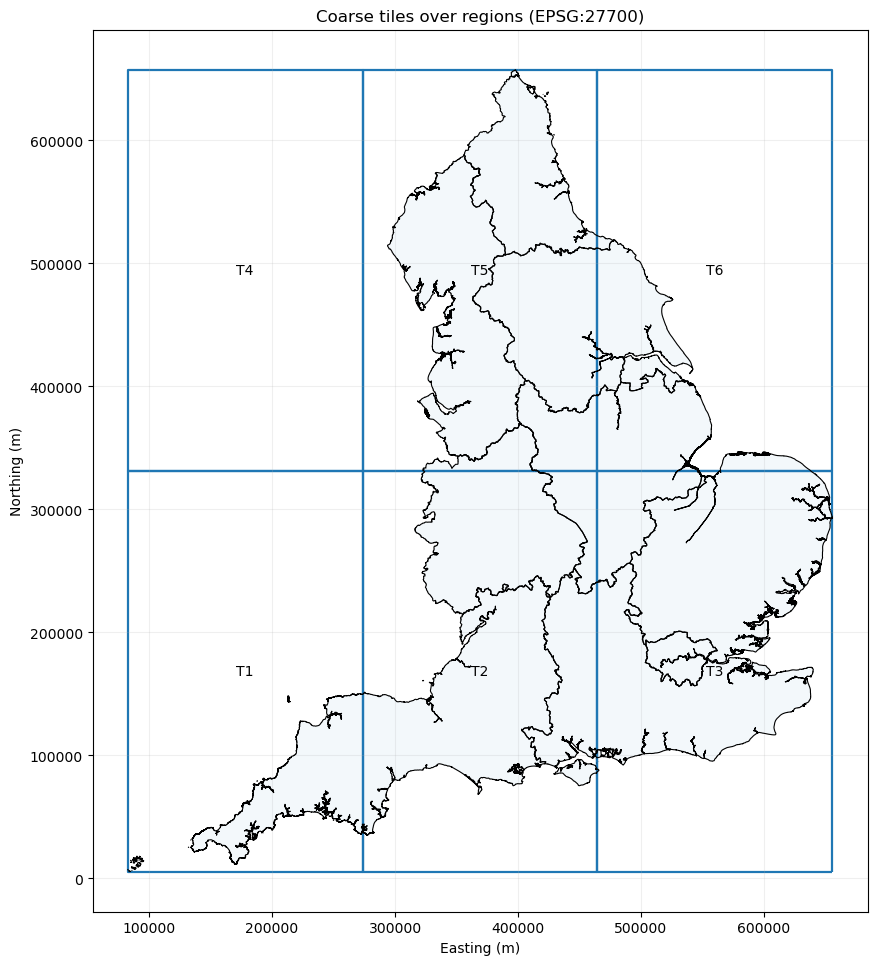

In [19]:
import matplotlib.pyplot as plt

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 12))
# Regions (outline + light fill)
REG.boundary.plot(ax=ax, linewidth=0.8, color="black")
REG.plot(ax=ax, alpha=0.05, edgecolor="none")

# Tiles (transparent fill, bold edges)
tiles.plot(ax=ax, facecolor="none", edgecolor="tab:blue", linewidth=1.6)

# Labels at tile centroids
tiles["cx"] = tiles.geometry.centroid.x
tiles["cy"] = tiles.geometry.centroid.y
for _, r in tiles.iterrows():
    ax.text(r["cx"], r["cy"], r["tile_id"], ha="center", va="center", fontsize=10)

ax.set_title("Coarse tiles over regions (EPSG:27700)")
ax.set_aspect("equal")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(True, alpha=0.2)

# pathlib.Path(OUT_PNG).parent.mkdir(parents=True, exist_ok=True)
# plt.tight_layout()
# plt.savefig(OUT_PNG, dpi=200)
# print(f"Saved: {OUT_PNG}")
plt.show()

In [24]:
tiles["geometry"][0].wkt

'POLYGON ((273580.32017766614 5424.788278571825, 273580.32017766614 331480.5067532951, 82607.34858326538 331480.5067532951, 82607.34858326538 5424.788278571825, 273580.32017766614 5424.788278571825))'

In [26]:
tiles

,tile_id,geometry,cx,cy
0,T1,"POLYGON ((273580.32 5424.788, 273580.32 331480...",178093.834380,168452.647516
1,T2,"POLYGON ((464553.292 5424.788, 464553.292 3314...",369066.805975,168452.647516
2,T3,"POLYGON ((655526.263 5424.788, 655526.263 3314...",560039.777569,168452.647516
3,T4,"POLYGON ((273580.32 331480.507, 273580.32 6575...",178093.834380,494508.365991
4,T5,"POLYGON ((464553.292 331480.507, 464553.292 65...",369066.805975,494508.365991
5,T6,"POLYGON ((655526.263 331480.507, 655526.263 65...",560039.777569,494508.365991


In [27]:
tiles_bounds = tiles.copy()
tiles_bounds[["minx", "miny", "maxx", "maxy"]] = tiles_bounds.geometry.bounds

In [28]:
tiles_bounds

,tile_id,geometry,cx,cy,minx,miny,maxx,maxy
0,T1,"POLYGON ((273580.32 5424.788, 273580.32 331480...",178093.834380,168452.647516,82607.348583,5424.788279,273580.320178,331480.506753
1,T2,"POLYGON ((464553.292 5424.788, 464553.292 3314...",369066.805975,168452.647516,273580.320178,5424.788279,464553.291772,331480.506753
2,T3,"POLYGON ((655526.263 5424.788, 655526.263 3314...",560039.777569,168452.647516,464553.291772,5424.788279,655526.263366,331480.506753
3,T4,"POLYGON ((273580.32 331480.507, 273580.32 6575...",178093.834380,494508.365991,82607.348583,331480.506753,273580.320178,657536.225228
4,T5,"POLYGON ((464553.292 331480.507, 464553.292 65...",369066.805975,494508.365991,273580.320178,331480.506753,464553.291772,657536.225228
5,T6,"POLYGON ((655526.263 331480.507, 655526.263 65...",560039.777569,494508.365991,464553.291772,331480.506753,655526.263366,657536.225228


In [29]:
# Build bbox string for API
tiles_bounds["bbox"] = (
    tiles_bounds["minx"].astype(int).astype(str) + "," +
    tiles_bounds["miny"].astype(int).astype(str) + "," +
    tiles_bounds["maxx"].astype(int).astype(str) + "," +
    tiles_bounds["maxy"].astype(int).astype(str)
)

In [30]:
tiles_bounds

,tile_id,geometry,cx,cy,minx,miny,maxx,maxy,bbox
0,T1,"POLYGON ((273580.32 5424.788, 273580.32 331480...",178093.834380,168452.647516,82607.348583,5424.788279,273580.320178,331480.506753,"82607,5424,273580,331480"
1,T2,"POLYGON ((464553.292 5424.788, 464553.292 3314...",369066.805975,168452.647516,273580.320178,5424.788279,464553.291772,331480.506753,"273580,5424,464553,331480"
2,T3,"POLYGON ((655526.263 5424.788, 655526.263 3314...",560039.777569,168452.647516,464553.291772,5424.788279,655526.263366,331480.506753,"464553,5424,655526,331480"
3,T4,"POLYGON ((273580.32 331480.507, 273580.32 6575...",178093.834380,494508.365991,82607.348583,331480.506753,273580.320178,657536.225228,"82607,331480,273580,657536"
4,T5,"POLYGON ((464553.292 331480.507, 464553.292 65...",369066.805975,494508.365991,273580.320178,331480.506753,464553.291772,657536.225228,"273580,331480,464553,657536"
5,T6,"POLYGON ((655526.263 331480.507, 655526.263 65...",560039.777569,494508.365991,464553.291772,331480.506753,655526.263366,657536.225228,"464553,331480,655526,657536"


In [31]:
# Keep just what you need
out = tiles_bounds[["tile_id", "bbox"]]

# Save to CSV
out.to_csv("tiles_coarse_bboxes.csv", index=False)

print(out)
print("Saved tiles_coarse_bboxes.csv")

  tile_id                         bbox
0      T1     82607,5424,273580,331480
1      T2    273580,5424,464553,331480
2      T3    464553,5424,655526,331480
3      T4   82607,331480,273580,657536
4      T5  273580,331480,464553,657536
5      T6  464553,331480,655526,657536
Saved tiles_coarse_bboxes.csv
